In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("/content/tripadvisor_hotel_reviews (2).csv")

df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [3]:
df.info()

df.shape

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


,0
Review,0
Rating,0


In [4]:
df = df.dropna()

In [5]:
df["Sentiment"] = df["Rating"]

df.loc[df["Rating"] >= 4, "Sentiment"] = "Positive"

df.loc[df["Rating"] == 3, "Sentiment"] = "Neutral"

df.loc[df["Rating"] <= 2, "Sentiment"] = "Negative"

df.head()

/tmp/ipykernel_1227/1727831038.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Positive' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df["Rating"] >= 4, "Sentiment"] = "Positive"


,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,Positive
1,ok nothing special charge diamond member hilto...,2,Negative
2,nice rooms not 4* experience hotel monaco seat...,3,Neutral
3,"unique, great stay, wonderful time hotel monac...",5,Positive
4,"great stay great stay, went seahawk game aweso...",5,Positive


In [6]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64


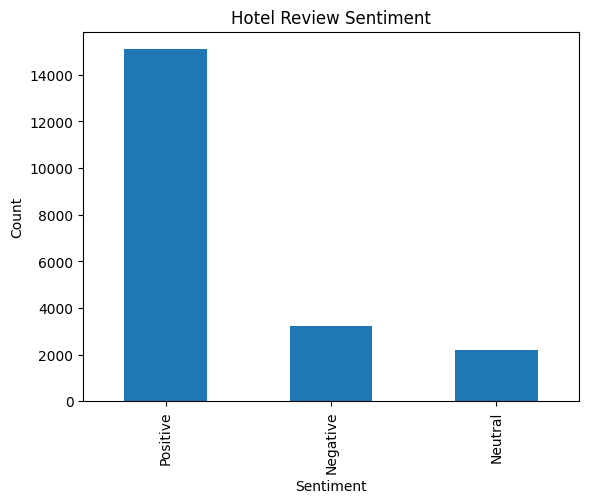

In [7]:
df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Hotel Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [8]:
df["Review"] = df["Review"].str.lower()

df["Review"] = df["Review"].str.replace(r"[^a-zA-Z ]","",regex=True)

df["Review"] = df["Review"].str.replace(r"\s+"," ",regex=True)

df.head()

,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,Positive
1,ok nothing special charge diamond member hilto...,2,Negative
2,nice rooms not experience hotel monaco seattle...,3,Neutral
3,unique great stay wonderful time hotel monaco ...,5,Positive
4,great stay great stay went seahawk game awesom...,5,Positive


In [9]:
X = df["Review"]

y = df["Sentiment"]

In [10]:
cv = CountVectorizer(stop_words="english")

X = cv.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [14]:
y_pred = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8387411563796048


In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       0.80      0.71      0.75       625
     Neutral       0.35      0.03      0.06       432
    Positive       0.85      0.98      0.91      3042

    accuracy                           0.84      4099
   macro avg       0.67      0.57      0.58      4099
weighted avg       0.79      0.84      0.80      4099



In [17]:
review = [
    "The room was clean and the staff were very friendly."
]

review = cv.transform(review)

prediction = model.predict(review)

print("Sentiment :", prediction[0])

Sentiment : Positive


In [18]:
review = [
    "The room was dirty and the food was terrible."
]

review = cv.transform(review)

prediction = model.predict(review)

print("Sentiment :", prediction[0])

Sentiment : Negative


In [19]:
negative = df[df["Sentiment"] == "Negative"]

print("Negative Reviews")

print(negative[["Review","Rating"]].head(10))

Negative Reviews
                                               Review  Rating
1   ok nothing special charge diamond member hilto...       2
10  poor value stayed monaco seattle july nice hot...       2
15  horrible customer service hotel stay february ...       1
16  disappointed say anticipating stay hotel monac...       2
24  great location need internally upgrade advanta...       2
32  noise airconditionera standard arranged stay t...       1
33  good location poor cleanliness warwick hotel g...       2
40  bad choice booked hotel hot wire called immedi...       1
42  warwick bad good reviews warwick shocks staff ...       2
44  austin powers decor familiar hotel seattlewher...       2


In [20]:
print("Room Related Reviews")

print(df[df["Review"].str.contains("room",case=False)][["Review","Rating"]].head())

Room Related Reviews
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not experience hotel monaco seattle...       3
3  unique great stay wonderful time hotel monaco ...       5
4  great stay great stay went seahawk game awesom...       5


In [21]:
print("Staff Related Reviews")

print(df[df["Review"].str.contains("staff",case=False)][["Review","Rating"]].head())

Staff Related Reviews
                                              Review  Rating
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not experience hotel monaco seattle...       3
3  unique great stay wonderful time hotel monaco ...       5
4  great stay great stay went seahawk game awesom...       5
5  love monaco staff husband stayed hotel crazy w...       5


In [22]:
print("Food Related Reviews")

print(df[df["Review"].str.contains("food",case=False)][["Review","Rating"]].head())

Food Related Reviews
                                               Review  Rating
5   love monaco staff husband stayed hotel crazy w...       5
7   excellent staff housekeeping quality hotel cho...       4
8   hotel stayed hotel monaco cruise rooms generou...       5
15  horrible customer service hotel stay february ...       1
19  hmmmmm say really high hopes hotel monaco chos...       3


In [23]:
print("Cleanliness Related Reviews")

print(df[df["Review"].str.contains("clean",case=False)][["Review","Rating"]].head())

Cleanliness Related Reviews
                                               Review  Rating
0   nice hotel expensive parking got good deal sta...       4
1   ok nothing special charge diamond member hilto...       2
6   cozy stay rainy city husband spent nights mona...       5
12  nice hotel good location hotel kimpton design ...       4
20  service service service spent week gfriend lab...       5


In [24]:
print("Service Related Reviews")

print(df[df["Review"].str.contains("service",case=False)][["Review","Rating"]].head())

Service Related Reviews
                                              Review  Rating
2  nice rooms not experience hotel monaco seattle...       3
3  unique great stay wonderful time hotel monaco ...       5
4  great stay great stay went seahawk game awesom...       5
5  love monaco staff husband stayed hotel crazy w...       5
7  excellent staff housekeeping quality hotel cho...       4


In [25]:
print("Hotel Review Report")

print("Total Reviews :", len(df))

print("Positive Reviews :", len(df[df["Sentiment"]=="Positive"]))

print("Neutral Reviews :", len(df[df["Sentiment"]=="Neutral"]))

print("Negative Reviews :", len(df[df["Sentiment"]=="Negative"]))

print("Model Accuracy :", round(accuracy*100,2), "%")

Hotel Review Report
Total Reviews : 20491
Positive Reviews : 15093
Neutral Reviews : 2184
Negative Reviews : 3214
Model Accuracy : 83.87 %
